<a href="https://colab.research.google.com/github/CalculatedContent/xgbwwdata/blob/main/longruns/AnalyzeLongRun_openml_312.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CalculatedContent/xgbwwdata/blob/main/AnalyzeLongRun.ipynb)


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Mount Google Drive when running in Google Colab
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('google.colab not available; skipping Drive mount.')


Mounted at /content/drive


In [18]:
!ls /content/drive/MyDrive/xgbww_runs/openml_w1w2w7w8w9_for_openml_id/

openml_1486_w1w2w7w8w9_alpha  openml_40983_w1w2w7w8w9_alpha
openml_312_w1w2w7w8w9_alpha   openml_4534_w1w2w7w8w9_alpha
openml_38_w1w2w7w8w9_alpha    selection_history.json


In [47]:
# Checkpoint produced by XGBWW_OpenML_1049_W7W8_Alpha_Checkpoint.ipynb
MODEL_ID = 312
RUN_NAME = f"openml_w1w2w7w8w9_for_openml_id/openml_{MODEL_ID}_w1w2w7w8w9_alpha"
METRICS_PATH = Path('/content/drive/MyDrive/xgbww_runs') / RUN_NAME / f"metrics_openml_{MODEL_ID}.csv"

df = pd.read_csv(METRICS_PATH)
display(df.tail(10))
print(f'Read {len(df)} rows from: {METRICS_PATH}')


,round,alpha_w1,alpha_w2,alpha_w7,alpha_w8,alpha_w9,D_w1,D_w2,D_w7,D_w8,...,num_traps_w9,ERG_gap_W1,ERG_gap_W2,ERG_gap_W7,ERG_gap_W8,ERG_gap_W9,train_acc,test_acc,test_logloss,elapsed_min
232,242,2.401889,2.502736,2.725571,2.157274,3.164722,0.034566,0.032597,0.052692,0.047590,...,1.0,-14.0,12.0,64.0,38.0,72.0,0.999481,0.979253,0.105755,297.162681
233,243,2.412342,2.486742,2.652821,2.134121,3.029930,0.035539,0.025906,0.041943,0.051505,...,1.0,-11.0,8.0,58.0,37.0,71.0,0.999481,0.979253,0.105854,299.109861
234,244,2.407752,2.482548,2.761400,2.178899,3.110169,0.028765,0.031856,0.056004,0.053395,...,1.0,-5.0,17.0,72.0,47.0,73.0,1.000000,0.979253,0.105766,301.064625
235,245,2.444185,2.485009,2.759844,2.212652,2.860712,0.033978,0.027961,0.056171,0.064838,...,1.0,-4.0,12.0,76.0,50.0,62.0,1.000000,0.979253,0.105840,303.032077
236,246,2.426477,2.477788,2.684408,2.181647,3.113441,0.032629,0.022399,0.047799,0.062112,...,1.0,0.0,14.0,67.0,48.0,71.0,1.000000,0.979253,0.105760,304.970819
237,247,2.457483,2.512022,2.766613,2.068412,3.040339,0.038230,0.029299,0.042299,0.051680,...,1.0,-6.0,10.0,67.0,27.0,67.0,1.000000,0.979253,0.105679,306.922673
238,248,2.383583,2.457505,2.816976,2.126769,3.098430,0.038788,0.028739,0.049078,0.054492,...,1.0,-13.0,6.0,78.0,34.0,69.0,1.000000,0.979253,0.105796,308.919048
239,249,2.405315,2.483054,2.806304,2.227241,3.188500,0.035738,0.030474,0.040564,0.054964,...,1.0,-11.0,12.0,72.0,47.0,76.0,1.000000,0.979253,0.105752,310.901564
240,250,2.420891,2.529122,2.848632,2.177897,3.181451,0.040633,0.035873,0.052894,0.056995,...,1.0,-3.0,18.0,78.0,48.0,75.0,1.000000,0.979253,0.105871,313.051593
241,251,2.427084,2.514796,2.775325,2.191565,3.198626,0.039377,0.032510,0.042650,0.056009,...,1.0,-7.0,13.0,70.0,46.0,76.0,1.000000,0.979253,0.105944,315.075900


Read 242 rows from: /content/drive/MyDrive/xgbww_runs/openml_w1w2w7w8w9_for_openml_id/openml_312_w1w2w7w8w9_alpha/metrics_openml_312.csv


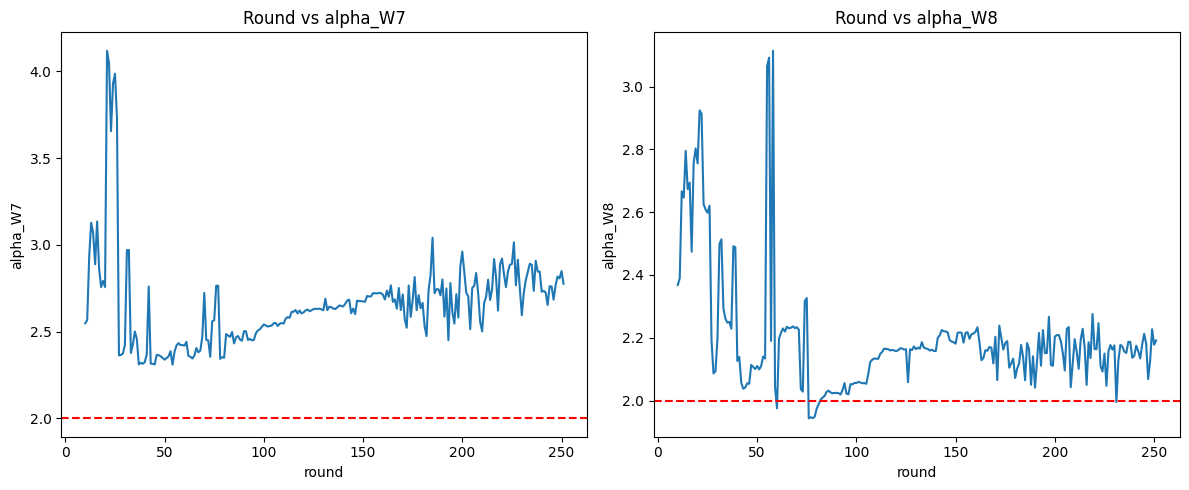

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax[0].plot(df['round'], df['alpha_w7'])
ax[0].set_title('Round vs alpha_W7')
ax[0].set_xlabel('round')
ax[0].set_ylabel('alpha_W7')
ax[0].axhline(y=2, color='r', linestyle='--')


ax[1].plot(df['round'], df['alpha_w8'])
ax[1].set_title('Round vs alpha_W8')
ax[1].set_xlabel('round')
ax[1].set_ylabel('alpha_W8')
ax[1].axhline(y=2, color='r', linestyle='--')

plt.tight_layout()
plt.show()


Text(0, 0.5, 'test accuracy')

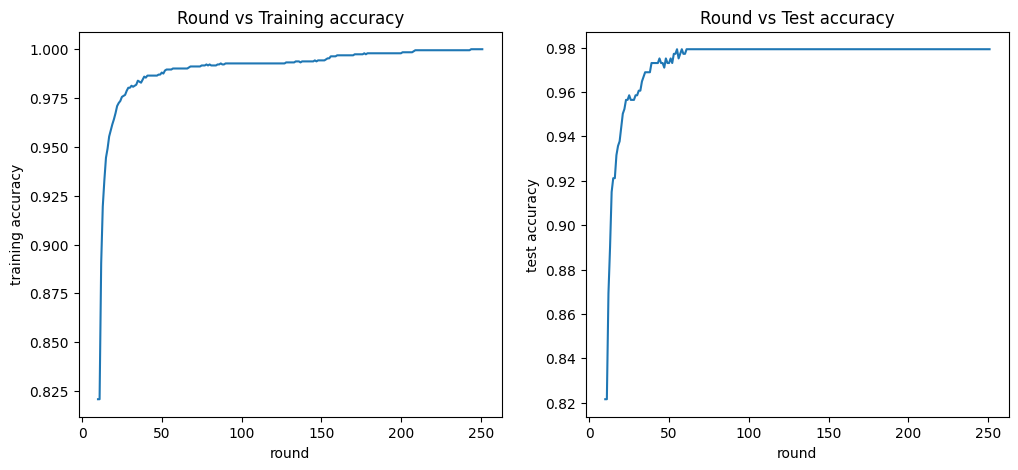

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax[0].plot(df['round'], df['train_acc'])
ax[0].set_title('Round vs Training accuracy')
ax[0].set_xlabel('round')
ax[0].set_ylabel('training accuracy')

ax[1].plot(df['round'], df['test_acc'])
ax[1].set_title('Round vs Test accuracy')
ax[1].set_xlabel('round')
ax[1].set_ylabel('test accuracy')


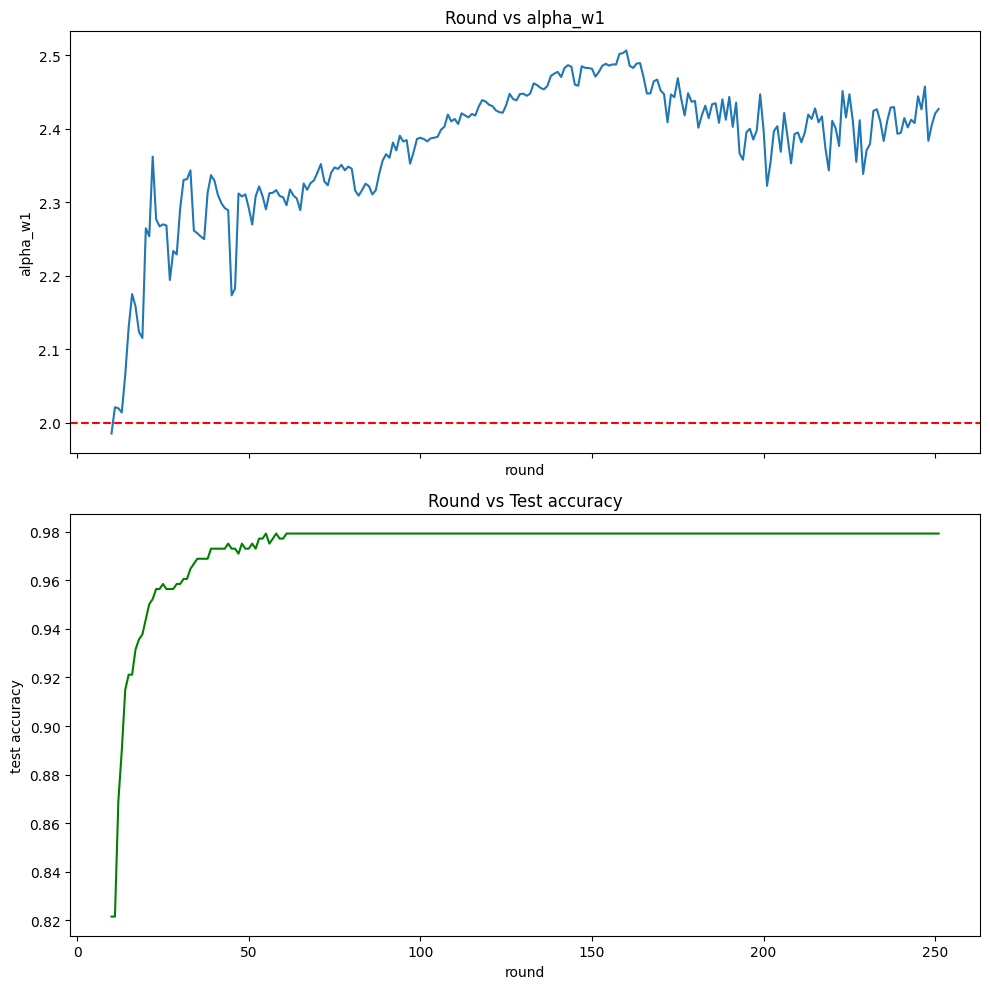

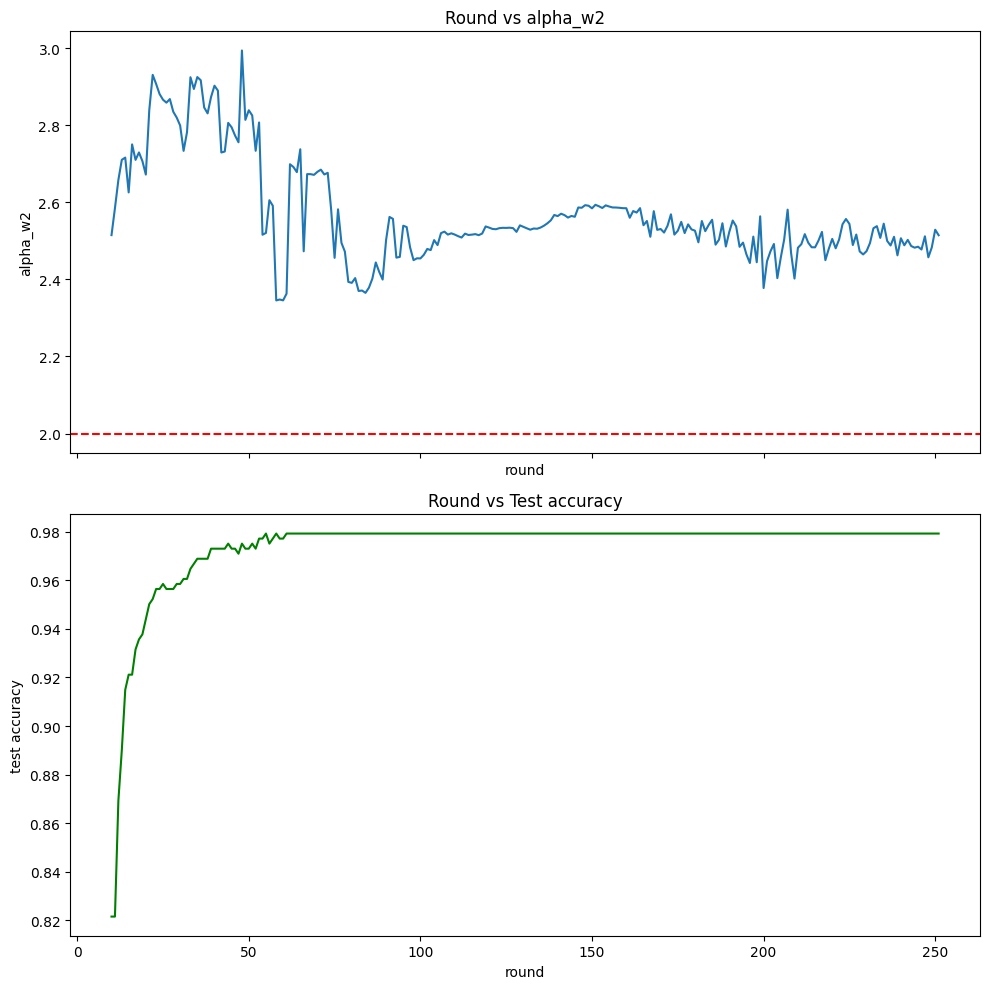

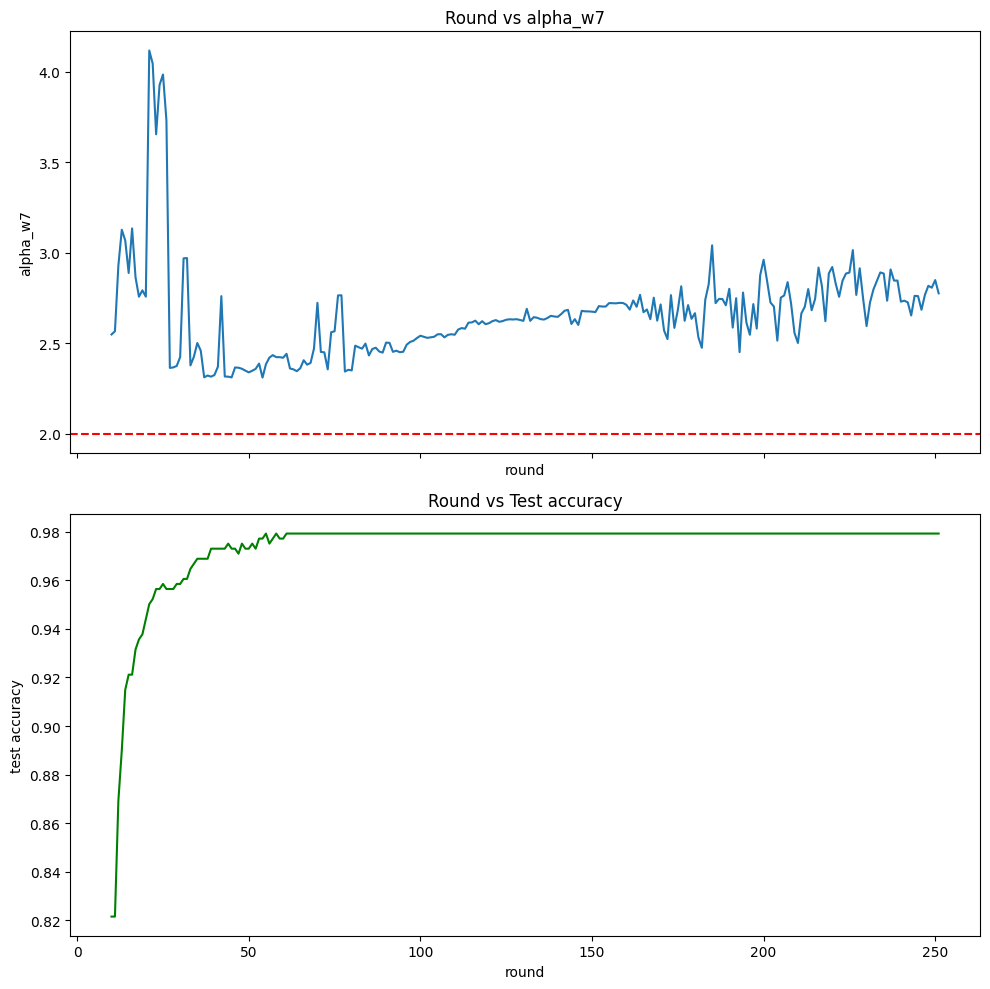

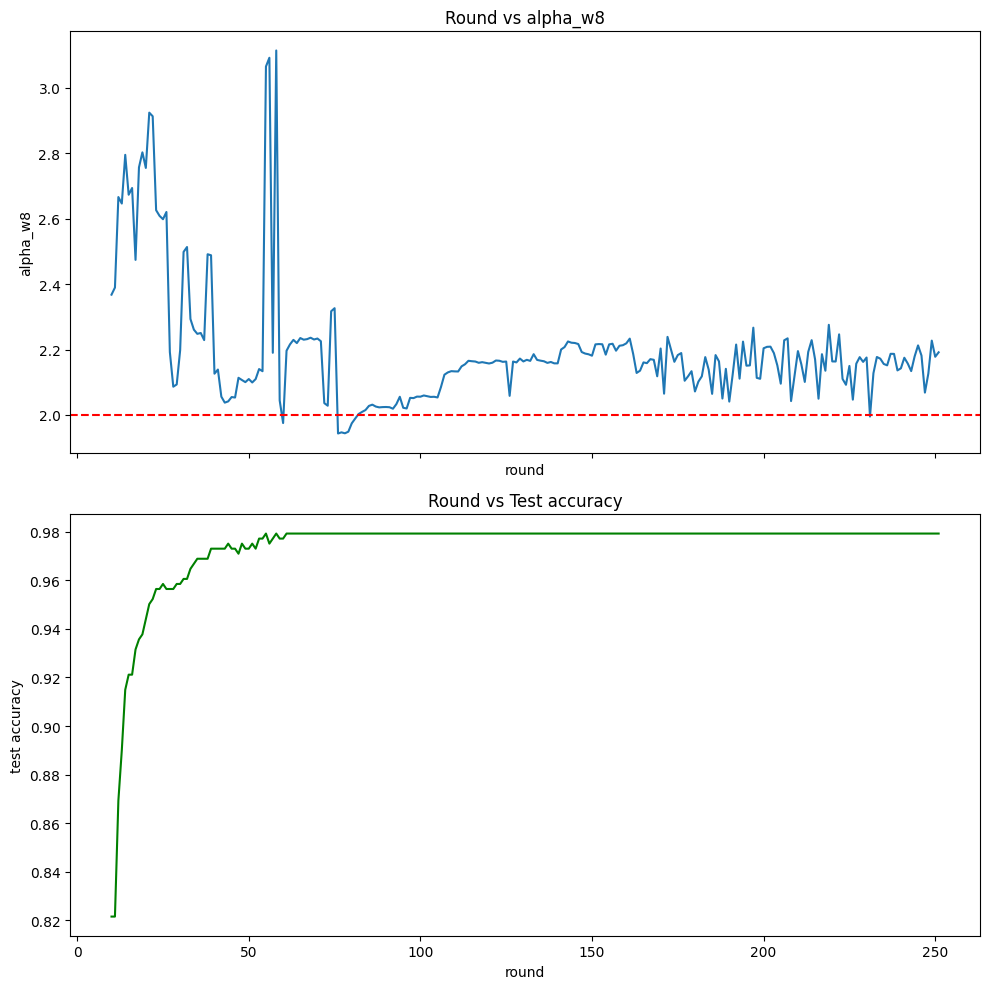

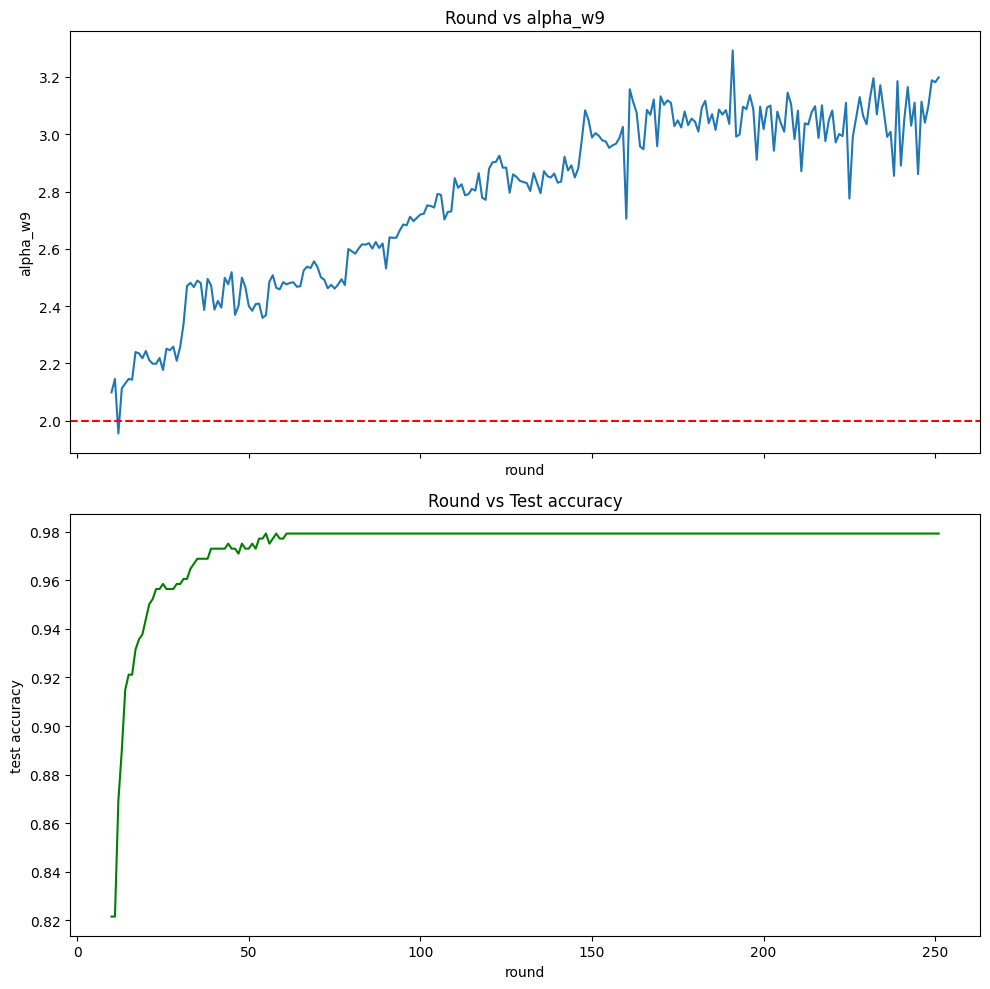

In [50]:

for wnum in [ "alpha_w1","alpha_w2","alpha_w7","alpha_w8","alpha_w9"]:
#for wnum in ["alpha_w7","alpha_w8"]:


  fig, ax = plt.subplots(2,1, figsize=(10,10), sharex=True)


  ax[0].plot(df['round'], df[wnum])
  ax[0].set_title('Round vs '+wnum)
  ax[0].set_xlabel('round')
  ax[0].set_ylabel(wnum)
  ax[0].axhline(y=2, color='r', linestyle='--')
  #ax[0].axvline(x=4800, color='orange', linestyle='--')

  ax[1].plot(df['round'], df['test_acc'],color='green')
  ax[1].set_title('Round vs Test accuracy')
  ax[1].set_xlabel('round')
  ax[1].set_ylabel('test accuracy')
  #ax[1].axvline(x=4800, color='orange', linestyle='--')

  #ax[0].axvline(x=5600, color='orange', linestyle='--')
  #ax[1].axvline(x=5600, color='orange', linestyle='--')


  plt.tight_layout()
  plt.show()

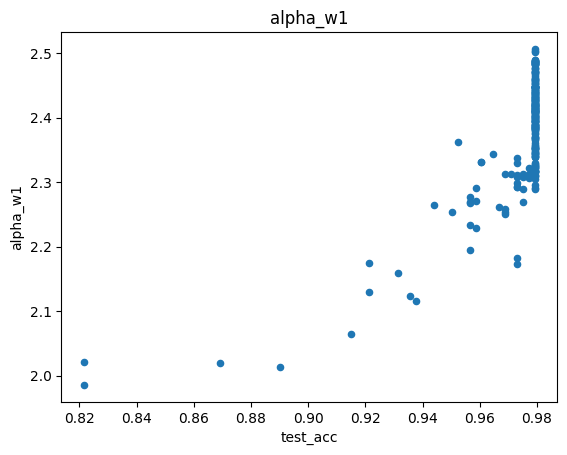

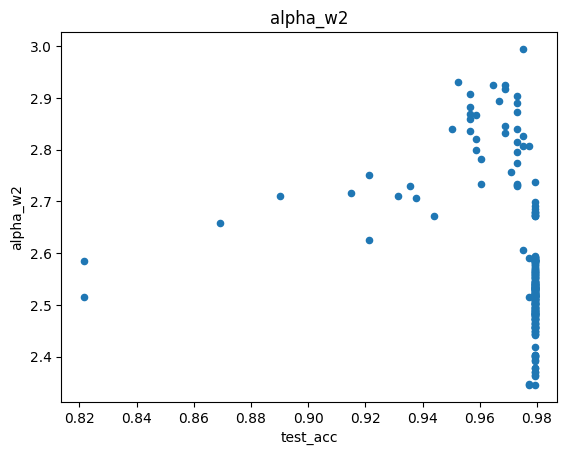

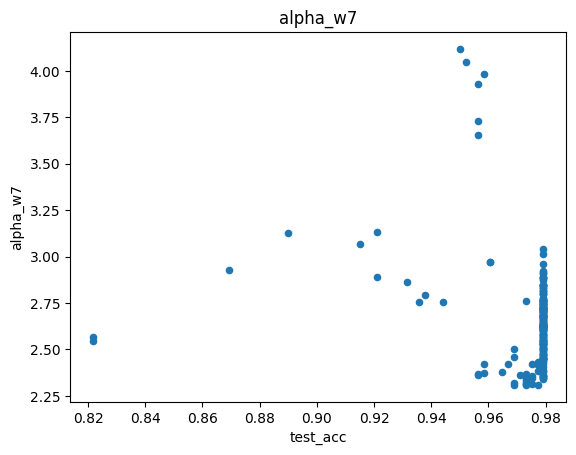

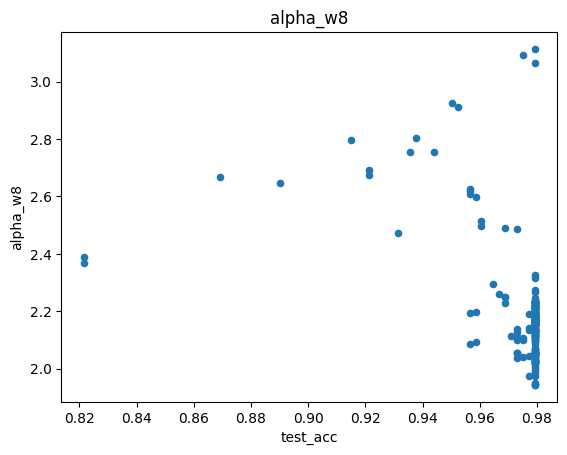

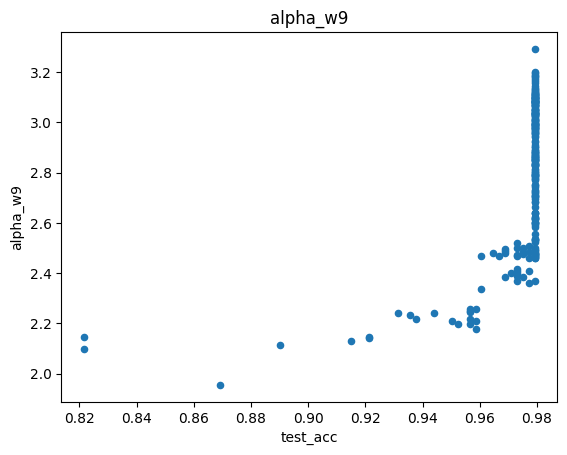

In [51]:
for wnum in [ "alpha_w1","alpha_w2","alpha_w7","alpha_w8","alpha_w9"]:
  df.plot.scatter(x='test_acc',y=wnum,title=wnum )


In [52]:
display(df.num_traps_w1.value_counts())
display(df.num_traps_w2.value_counts())
display(df.num_traps_w7.value_counts())
display(df.num_traps_w8.value_counts())
display(df.num_traps_w9.value_counts())

,count
num_traps_w1,
0.0,242


,count
num_traps_w2,
0.0,242


,count
num_traps_w7,
0.0,242


,count
num_traps_w8,
0.0,214
1.0,26
2.0,2


,count
num_traps_w9,
1.0,152
5.0,87
0.0,1
4.0,1
2.0,1


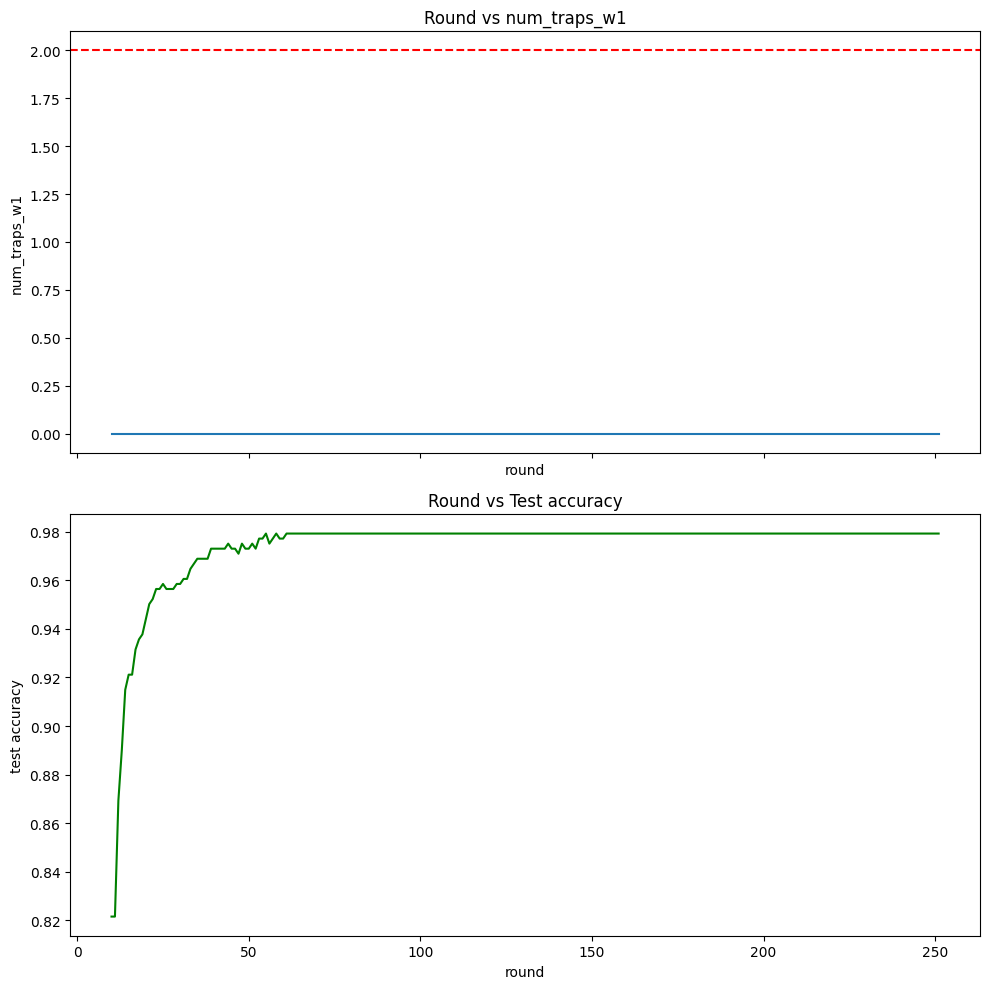

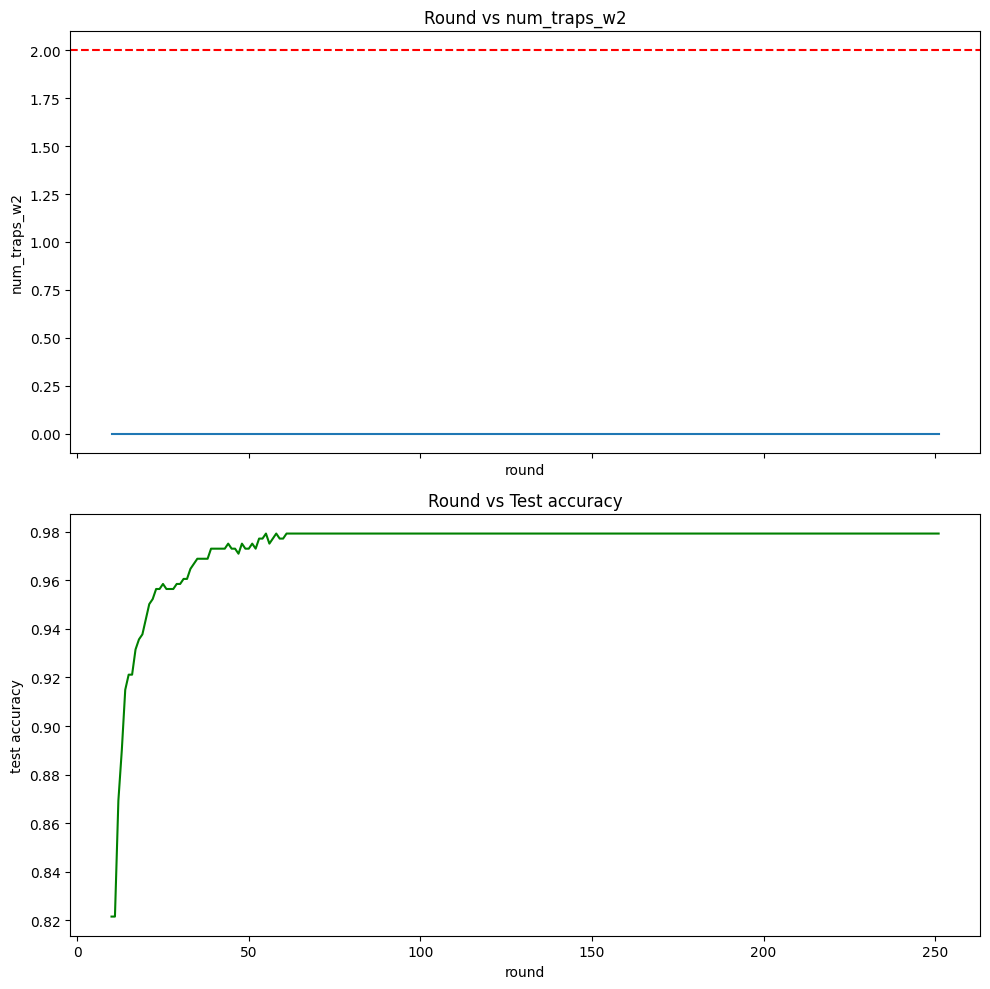

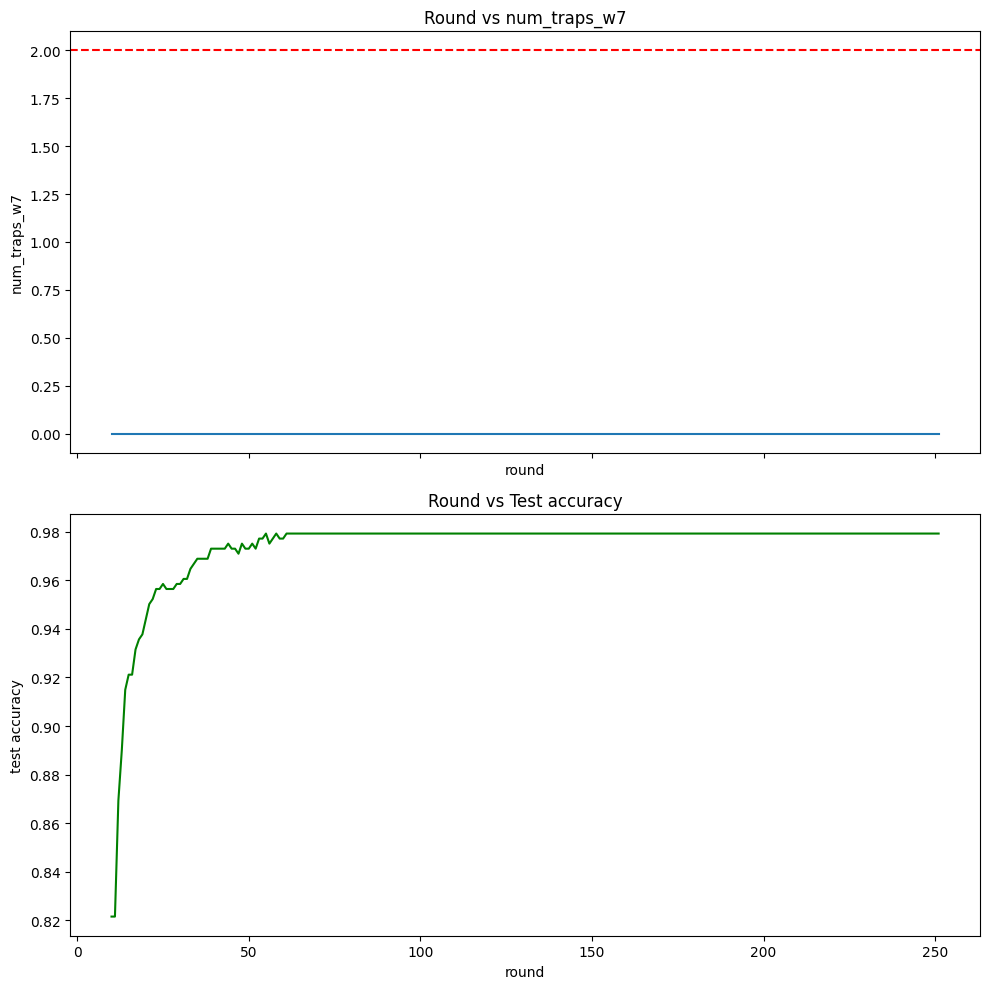

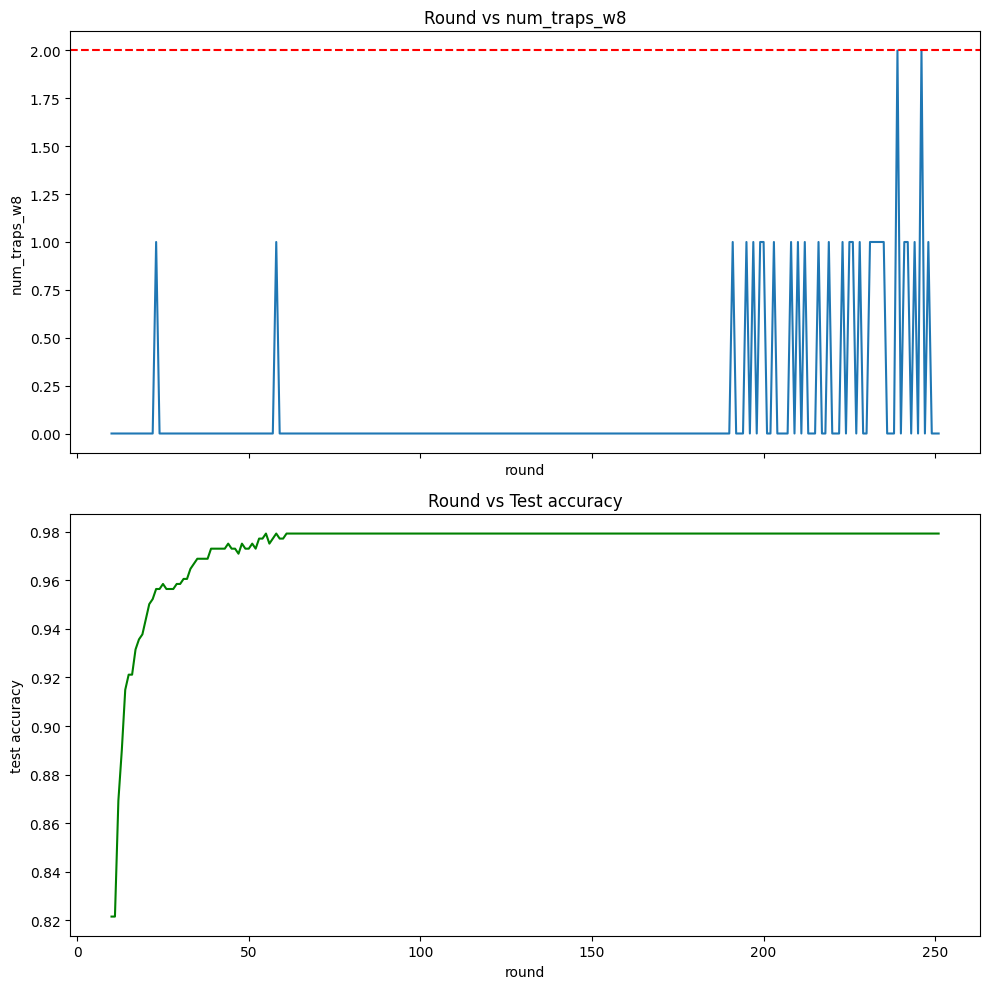

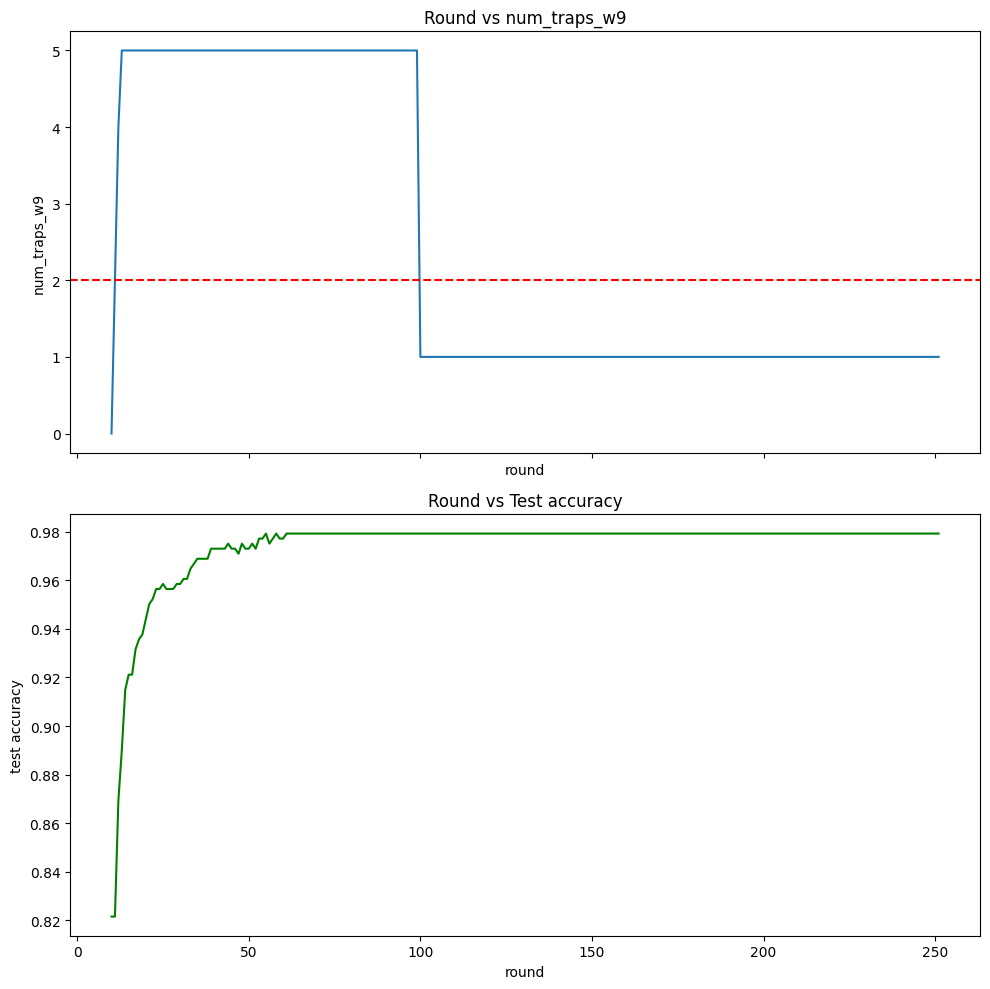

In [53]:

for wnum in [ "num_traps_w1","num_traps_w2","num_traps_w7","num_traps_w8","num_traps_w9"]:

  fig, ax = plt.subplots(2,1, figsize=(10,10), sharex=True)


  ax[0].plot(df['round'], df[wnum])
  ax[0].set_title('Round vs '+wnum)
  ax[0].set_xlabel('round')
  ax[0].set_ylabel(wnum)
  ax[0].axhline(y=2, color='r', linestyle='--')
  #ax[0].axvline(x=4800, color='orange', linestyle='--')

  ax[1].plot(df['round'], df['test_acc'],color='green')
  ax[1].set_title('Round vs Test accuracy')
  ax[1].set_xlabel('round')
  ax[1].set_ylabel('test accuracy')
  #ax[1].axvline(x=4800, color='orange', linestyle='--')

  #ax[0].axvline(x=5600, color='orange', linestyle='--')
  #ax[1].axvline(x=5600, color='orange', linestyle='--')


  plt.tight_layout()
  plt.show()

In [54]:
df.num_traps_w8.sum()

np.float64(30.0)

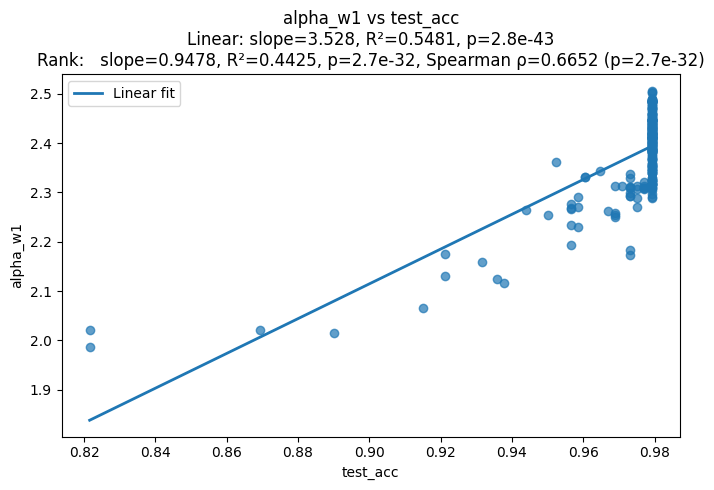

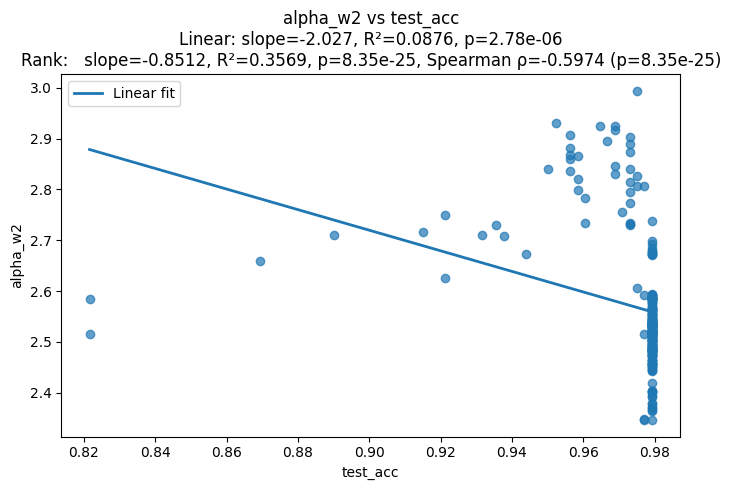

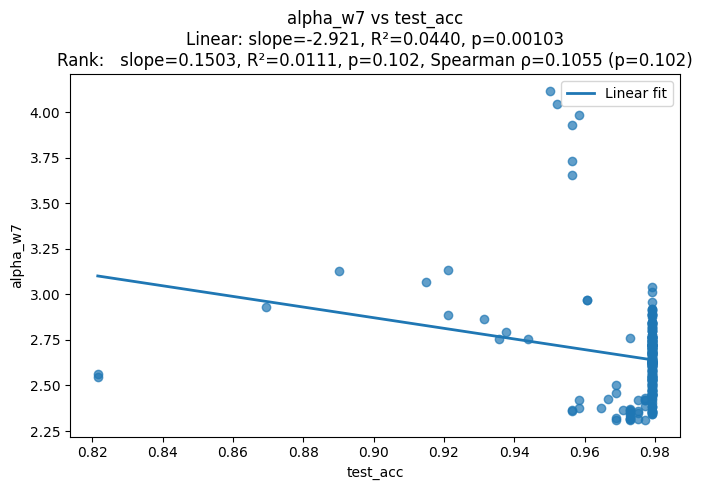

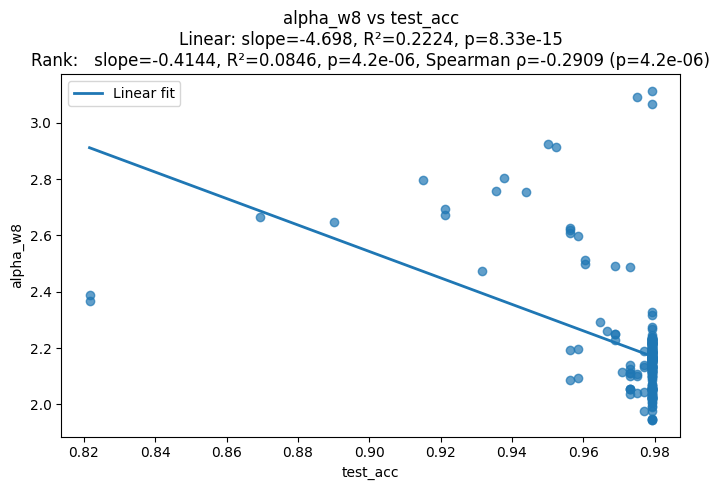

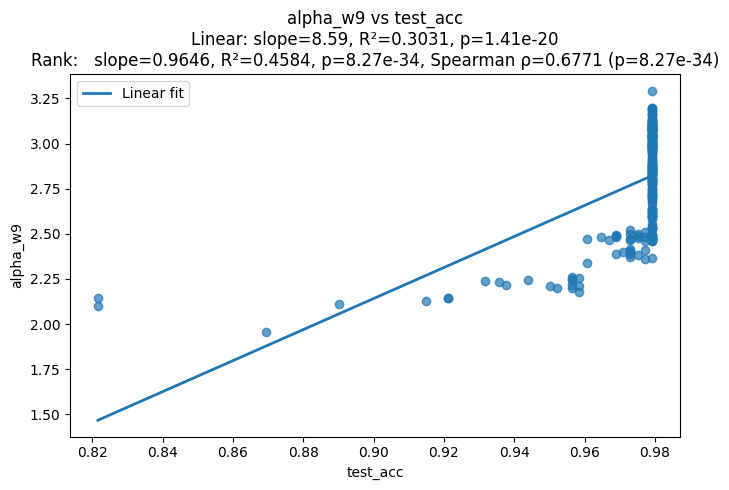

,ycol,n,linear_slope,linear_intercept,linear_r,linear_r2,linear_p,linear_stderr,rank_slope,rank_intercept,rank_r,rank_r2,rank_p,rank_stderr,spearman_rho,spearman_p
0,alpha_w1,242,3.5284,-1.0611,0.7403,0.5481,0.000,0.2068,0.9478,6.3452,0.6652,0.4425,0.0000,0.0687,0.6652,0.0000
1,alpha_w2,242,-2.0265,4.5436,-0.2960,0.0876,0.000,0.4221,-0.8512,224.9206,-0.5974,0.3569,0.0000,0.0737,-0.5974,0.0000
2,alpha_w7,242,-2.9206,5.5008,-0.2097,0.0440,0.001,0.8791,0.1503,103.2373,0.1055,0.0111,0.1016,0.0915,0.1055,0.1016
3,alpha_w8,242,-4.6983,6.7715,-0.4716,0.2224,0.000,0.5670,-0.4144,171.8476,-0.2909,0.0846,0.0000,0.0880,-0.2909,0.0000
4,alpha_w9,242,8.5899,-5.5891,0.5505,0.3031,0.000,0.8409,0.9646,4.2962,0.6771,0.4584,0.0000,0.0677,0.6771,0.0000


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, rankdata, spearmanr

results = []

xcol = "test_acc"
ycols = ["alpha_w1", "alpha_w2", "alpha_w7", "alpha_w8", "alpha_w9"]

for ycol in ycols:
    # keep only finite values
    sub = df[[xcol, ycol]].replace([np.inf, -np.inf], np.nan).dropna()
    x = sub[xcol].to_numpy()
    y = sub[ycol].to_numpy()

    if len(sub) < 3:
        print(f"Skipping {ycol}: not enough data")
        continue

    # -----------------------------
    # 1) simple linear regression
    # -----------------------------
    lr = linregress(x, y)

    # fitted line
    xs = np.linspace(x.min(), x.max(), 200)
    ys = lr.intercept + lr.slope * xs

    # -----------------------------
    # 2) rank regression
    #    regress rank(y) on rank(x)
    # -----------------------------
    xr = rankdata(x, method="average")
    yr = rankdata(y, method="average")
    rr = linregress(xr, yr)

    # also report Spearman as a standard rank-based statistic
    sp = spearmanr(x, y)

    # -----------------------------
    # 3) plot
    # -----------------------------
    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.7)
    plt.plot(xs, ys, linewidth=2, label="Linear fit")

    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(
        f"{ycol} vs {xcol}\n"
        f"Linear: slope={lr.slope:.4g}, R²={lr.rvalue**2:.4f}, p={lr.pvalue:.3g}\n"
        f"Rank:   slope={rr.slope:.4g}, R²={rr.rvalue**2:.4f}, p={rr.pvalue:.3g}, "
        f"Spearman ρ={sp.statistic:.4f} (p={sp.pvalue:.3g})"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    # save stats
    results.append({
        "ycol": ycol,
        "n": len(sub),

        "linear_slope": lr.slope,
        "linear_intercept": lr.intercept,
        "linear_r": lr.rvalue,
        "linear_r2": lr.rvalue**2,
        "linear_p": lr.pvalue,
        "linear_stderr": lr.stderr,

        "rank_slope": rr.slope,
        "rank_intercept": rr.intercept,
        "rank_r": rr.rvalue,
        "rank_r2": rr.rvalue**2,
        "rank_p": rr.pvalue,
        "rank_stderr": rr.stderr,

        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
    })

# -----------------------------
# 4) report stats table
# -----------------------------
stats_df = pd.DataFrame(results)
display(stats_df.round(4))